%%markdown
| Column | Description |
|--------|-------------|
| `id` | A unique identifier for each car listing |
| `brand` | The manufacturer of the vehicle (e.g., BMW, Ford, Mercedes-Benz) |
| `model` | The specific model name within the brand (e.g., X5, F-150, M3) |
| `model_year` | The year the vehicle was manufactured |
| `milage` | The total distance the vehicle has been driven in miles |
| `fuel_type` | The type of fuel the vehicle uses (e.g., Gasoline, Hybrid, Diesel) |
| `engine` | Raw text describing engine specs including horsepower, displacement, and cylinders |
| `transmission` | Whether the vehicle has an Automatic or Manual transmission |
| `ext_col` | The exterior color of the vehicle |
| `int_col` | The interior color of the vehicle |
| `accident` | Whether the vehicle has a reported accident or damage history |
| `clean_title` | Whether the vehicle has a clean ownership title with no salvage or rebuilt status |
| `price` | The listed selling price of the used car in USD — this is the **target variable** |

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# <center> Data Overview </center>

In [2]:
df= pd.read_csv('car_price_Prediction.csv')
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,Ford,F-150 Lariat,2018,74349,Gasoline,375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,10-Speed A/T,Blue,Gray,None reported,Yes,11000
1,1,BMW,335 i,2007,80000,Gasoline,300.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,Black,Black,None reported,Yes,8250
2,2,Jaguar,XF Luxury,2009,91491,Gasoline,300.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,6-Speed A/T,Purple,Beige,None reported,Yes,15000
3,3,BMW,X7 xDrive40i,2022,2437,Hybrid,335.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Transmission w/Dual Shift Mode,Gray,Brown,None reported,Yes,63500
4,4,Pontiac,Firebird Base,2001,111000,Gasoline,200.0HP 3.8L V6 Cylinder Engine Gasoline Fuel,A/T,White,Black,None reported,Yes,7850


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54273 entries, 0 to 54272
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            54273 non-null  int64 
 1   brand         54273 non-null  object
 2   model         54273 non-null  object
 3   model_year    54273 non-null  int64 
 4   milage        54273 non-null  int64 
 5   fuel_type     54273 non-null  object
 6   engine        54273 non-null  object
 7   transmission  54273 non-null  object
 8   ext_col       54273 non-null  object
 9   int_col       54273 non-null  object
 10  accident      54273 non-null  object
 11  clean_title   54273 non-null  object
 12  price         54273 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.4+ MB


In [4]:
df.isnull().mean()*100

id              0.0
brand           0.0
model           0.0
model_year      0.0
milage          0.0
fuel_type       0.0
engine          0.0
transmission    0.0
ext_col         0.0
int_col         0.0
accident        0.0
clean_title     0.0
price           0.0
dtype: float64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
for col in df.select_dtypes('O').columns:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print('-'*50)

brand
53
['Ford' 'BMW' 'Jaguar' 'Pontiac' 'Acura' 'Audi' 'GMC' 'Maserati'
 'Chevrolet' 'Porsche' 'Mercedes-Benz' 'Tesla' 'Lexus' 'Kia' 'Lincoln'
 'Dodge' 'Volkswagen' 'Land' 'Cadillac' 'Mazda' 'RAM' 'Subaru' 'Hyundai'
 'MINI' 'Jeep' 'Honda' 'Hummer' 'Nissan' 'Toyota' 'Volvo' 'Genesis'
 'Mitsubishi' 'Buick' 'INFINITI' 'McLaren' 'Scion' 'Lamborghini' 'Bentley'
 'Suzuki' 'Ferrari' 'Alfa' 'Rolls-Royce' 'Chrysler' 'Aston' 'Rivian'
 'Lotus' 'Saturn' 'Lucid' 'Mercury' 'Maybach' 'FIAT' 'Plymouth' 'Bugatti']
--------------------------------------------------
model
1827
['F-150 Lariat' '335 i' 'XF Luxury' ... 'Q4 e-tron Sportback Premium'
 'Countryman Cooper' 'S-10 LS']
--------------------------------------------------
fuel_type
7
['Gasoline' 'Hybrid' 'E85 Flex Fuel' 'Diesel' '–' 'Plug-In Hybrid'
 'not supported']
--------------------------------------------------
engine
1061
['375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel'
 '300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel'
 '300.0HP 4.2L

In [7]:
for col in df.select_dtypes('O').columns:
    print(f"Column: {col}")
    print(df[col].nunique())
    print(df[col].value_counts())
    print('='*50)

Column: brand
53
brand
BMW              7369
Ford             6706
Mercedes-Benz    5087
Chevrolet        4424
Audi             2922
Porsche          2627
Toyota           2315
Lexus            2257
Jeep             2247
Land             1995
Cadillac         1565
Nissan           1252
GMC              1076
Dodge            1011
RAM               966
INFINITI          957
Lincoln           767
Mazda             748
Subaru            739
Hyundai           694
Jaguar            661
Volkswagen        628
Honda             624
Acura             580
Kia               526
Volvo             452
MINI              364
Maserati          293
Bentley           284
Chrysler          258
Genesis           249
Buick             228
Mitsubishi        182
Hummer            176
Pontiac           149
Alfa              144
Rolls-Royce       142
Lamborghini       122
Tesla             110
Ferrari            87
Saturn             58
Scion              53
Aston              50
McLaren            43
Rivian   

# Categorical Columns — Issues & Cleaning Plan

| Column | Issue | Fix |
|---|---|---|
| `fuel_type` | Hidden missing — `"–"` (294) and `"not supported"` (4) | Replace with `NaN` → `fillna` mode |
| `engine` | Unstructured free text mixing HP, size, cylinders | Regex extract → 3 new columns, drop original |
| `transmission` | 46 inconsistent variants + invalid entries (`"–"`, `"F"`) | Map → `Automatic` / `Manual` / `Other` |
| `ext_col` | 260 color variants — brand names for same base color | Keep top 10, rest → `"Other"` |
| `int_col` | 124 variants + case inconsistency (`"BLACK"`, `"Blk"`) | `str.lower()` first, keep top 10, rest → `"Other"` |
| `model` | 1,827 unique values — too high cardinality | Keep top 20, rest → `"Other"` |
| `accident` | Long text strings instead of binary | Map → `0` / `1` |
| `clean_title` | Zero-variance — only `"Yes"` across all rows | Drop |

# <center> Cleaning & Feature engineering </center>

In [8]:
# ── 1. fuel_type — Hidden Missing Values
df['fuel_type'] = df['fuel_type'].replace(['–', 'not supported'], np.nan)


In [9]:
# Extract each feature separately 
df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)(?=HP)')[0].astype(float)        # number before HP → horsepower
df['engine_size_liters'] = df['engine'].str.extract(r'(\d+\.?\d*)(?=L)')[0].astype(float) # number before L → engine size
df['num_cylinders'] = df['engine'].str.extract(r'(\d+)\s*Cylinder')[0].astype(float)      # number before Cylinder → cylinders count

df.drop(columns='engine', inplace=True)

In [10]:
# Convert transmission column into 2 main categories

def standardize_transmission(val):
    if pd.isna(val):
        return np.nan  # keep missing values

    # Automatic transmissions group
    if any(k in str(val) for k in ['A/T', 'Automatic', 'CVT', 'DCT', 'Auto-Shift']):
        return 'Automatic'

    # Manual transmissions group
    if any(k in str(val) for k in ['M/T', 'Manual', 'Mt']):
        return 'Manual'

    return np.nan  # unclear values


# Apply function to column
df['transmission'] = df['transmission'].apply(standardize_transmission)

In [11]:
# Replace invalid values 
df['ext_col'].replace('–', np.nan, inplace=True)

# Get top 10 most frequent exterior colors
top_ext = df['ext_col'].value_counts().head(10).index

# Keep top 10 colors, and group everything else as 'Other'
df['ext_col'] = df['ext_col'].apply(lambda x: x if x in top_ext else 'Other')

C:\Users\Seif Taher\AppData\Local\Temp\ipykernel_15756\2450800623.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ext_col'].replace('–', np.nan, inplace=True)


In [12]:
df['int_col'].replace('–', np.nan, inplace=True)

df['int_col'] = df['int_col'].str.lower().str.strip()

# Get top 10 most frequent interior colors
top_int = df['int_col'].value_counts().head(10).index

# Keep top 10, group the rest as 'Other'
df['int_col'] = df['int_col'].apply(lambda x: x if x in top_int else 'Other')

C:\Users\Seif Taher\AppData\Local\Temp\ipykernel_15756\1566559085.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['int_col'].replace('–', np.nan, inplace=True)


In [13]:
cylinder_map = {
    3: "cyl_3",
    4: "cyl_4",
    5: "cyl_5",
    6: "cyl_6",
    8: "cyl_8",
    10: "cyl_10",
    12: "cyl_12"
}

df["num_cylinders"] = df["num_cylinders"].map(cylinder_map)

In [14]:
# Keep only the top 5 most frequent models within each brand
# Replace all other less frequent models with "Other" to reduce cardinality
top_models = (
    df.groupby('brand')['model']
      .apply(lambda x: x.value_counts().head(3).index.tolist())
      .to_dict()
)

df['model'] = df.apply(
    lambda row: row['model']
    if row['model'] in top_models[row['brand']]
    else 'Other',
    axis=1
)

<Axes: xlabel='count', ylabel='model'>

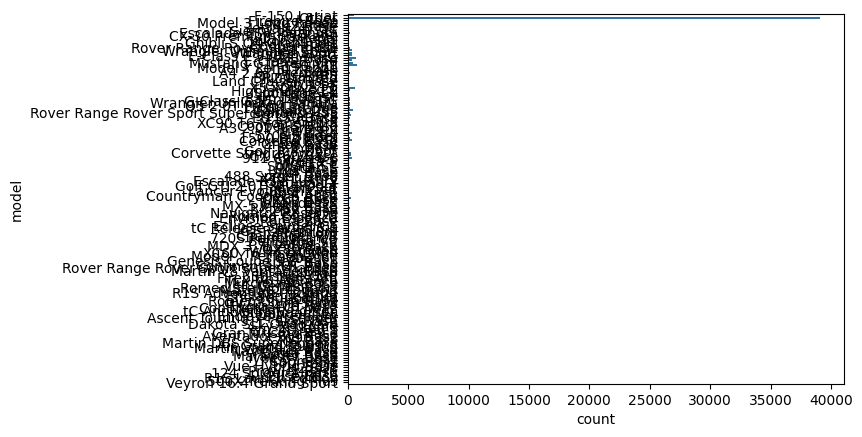

In [15]:
sns.countplot(data = df , y = 'model')

In [16]:
df.drop(columns=['id','clean_title','model','accident'], inplace=True)

In [17]:
df.head()

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
0,Ford,2018,74349,Gasoline,Automatic,Blue,gray,11000,375.0,3.5,cyl_6
1,BMW,2007,80000,Gasoline,Manual,Black,black,8250,300.0,3.0,cyl_6
2,Jaguar,2009,91491,Gasoline,Automatic,Other,beige,15000,300.0,4.2,cyl_8
3,BMW,2022,2437,Hybrid,NaN,Gray,brown,63500,335.0,3.0,cyl_6
4,Pontiac,2001,111000,Gasoline,Automatic,White,black,7850,200.0,3.8,cyl_6


In [18]:
df.to_csv("cars_updated_2.csv", index=False)

# <center> EDA </center>

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54273 entries, 0 to 54272
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brand               54273 non-null  object 
 1   model_year          54273 non-null  int64  
 2   milage              54273 non-null  int64  
 3   fuel_type           53975 non-null  object 
 4   transmission        47744 non-null  object 
 5   ext_col             54273 non-null  object 
 6   int_col             54273 non-null  object 
 7   price               54273 non-null  int64  
 8   horsepower          50216 non-null  float64
 9   engine_size_liters  53667 non-null  float64
 10  num_cylinders       50098 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 4.6+ MB


In [19]:
df.describe().round(2)

,model_year,milage,price,horsepower,engine_size_liters
count,54273.00,54273.00,54273.00,50216.00,53667.00
mean,2015.09,72746.18,39218.44,331.70,3.72
std,5.59,50469.49,72826.34,108.05,1.34
min,1974.00,100.00,2000.00,76.00,0.65
25%,2012.00,32268.00,15500.00,255.00,3.00
50%,2016.00,66107.00,28000.00,310.00,3.50
75%,2019.00,102000.00,45000.00,400.00,4.60
max,2024.00,405000.00,2954083.00,1020.00,8.40


In [20]:
df[df['milage']==100]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
4285,Lexus,2016,100,Gasoline,NaN,White,black,112000,386.0,4.6,cyl_8
10648,Ford,2022,100,Gasoline,Automatic,Gray,brown,62499,315.0,2.7,cyl_6
21305,GMC,2022,100,Diesel,Automatic,Red,black,60000,277.0,3.0,cyl_6


In [21]:
df[df['milage']==405000]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
8674,Mazda,2016,405000,Gasoline,Manual,Brown,black,16750,155.0,2.0,cyl_4
39640,Chevrolet,2004,405000,Gasoline,Manual,Other,black,15000,345.0,5.7,cyl_8
40126,Kia,2018,405000,Gasoline,Automatic,White,beige,26497,185.0,2.4,cyl_4
46001,Honda,2013,405000,Gasoline,Automatic,Black,black,4399,185.0,2.4,cyl_4


In [22]:
df[df['milage']>=250000]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
111,Volvo,2004,257700,Gasoline,Manual,Red,beige,8000,218.0,2.5,cyl_5
159,Toyota,2012,269885,Gasoline,Automatic,Black,brown,47500,381.0,5.7,cyl_8
720,Toyota,2016,269885,Gasoline,Automatic,Black,black,29500,381.0,5.7,cyl_8
1082,Ford,1999,300183,Gasoline,Automatic,Black,gray,25500,220.0,4.6,cyl_8
1240,Ford,2011,271000,Gasoline,Automatic,Red,gray,9500,300.0,5.4,cyl_8
...,...,...,...,...,...,...,...,...,...,...,...
52036,Ford,2022,251634,Diesel,Automatic,Red,black,46500,475.0,6.7,cyl_8
53204,Dodge,2006,300183,Gasoline,Automatic,Blue,gray,6995,345.0,5.7,cyl_8
53580,Dodge,2007,256000,Gasoline,Automatic,Silver,gray,5000,210.0,3.7,cyl_6
53628,Toyota,2018,259500,Gasoline,Automatic,White,Other,197750,NaN,5.7,NaN


In [23]:
df[df['price']==2000.00]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
698,Honda,2008,190640,Gasoline,Manual,Black,beige,2000,140.0,1.8,cyl_4
23777,Jaguar,1997,140000,Gasoline,Automatic,Black,beige,2000,290.0,4.0,cyl_8
26282,Honda,2011,175000,Gasoline,Automatic,Black,beige,2000,250.0,3.5,cyl_6
28863,Jeep,2004,179700,Gasoline,Automatic,Silver,black,2000,190.0,4.0,cyl_6
30556,Chevrolet,1996,60000,Gasoline,Automatic,Other,beige,2000,260.0,5.7,cyl_8
31312,Porsche,2005,96275,Gasoline,Manual,Silver,black,2000,300.0,3.4,cyl_6
35335,Hyundai,2013,166200,Gasoline,Automatic,White,black,2000,200.0,2.4,cyl_4
39152,Mazda,2005,205000,Gasoline,Automatic,Silver,black,2000,273.0,3.7,cyl_6
42062,Chevrolet,1999,47000,Gasoline,Automatic,Gold,beige,2000,305.0,5.7,cyl_8
42443,Mazda,2003,120000,Gasoline,Manual,Silver,black,2000,140.0,1.8,cyl_4


In [24]:
df[df['price']==2954083.00]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
5584,Mercedes-Benz,2004,2533,Gasoline,Automatic,White,beige,2954083,302.0,5.0,cyl_8
7620,Chevrolet,2005,231581,Gasoline,Automatic,Gray,beige,2954083,400.0,6.0,cyl_8
7849,GMC,2005,231500,Gasoline,Automatic,Red,beige,2954083,355.0,5.3,cyl_8
10374,Chevrolet,2015,23442,Gasoline,Automatic,Red,gray,2954083,355.0,5.3,cyl_8
13913,Chevrolet,2006,110000,Gasoline,NaN,Red,beige,2954083,355.0,5.3,cyl_8
14389,GMC,2006,231500,Gasoline,Automatic,Red,gray,2954083,295.0,5.3,cyl_8
19661,Audi,2017,54500,Diesel,Automatic,Black,brown,2954083,NaN,3.0,cyl_6
20007,RAM,2019,10458,Gasoline,Automatic,Red,black,2954083,NaN,5.7,NaN
29826,Toyota,2002,17300,Gasoline,Automatic,Silver,gray,2954083,381.0,5.7,cyl_8
34049,Acura,2021,2353,Gasoline,Automatic,Red,ebony,2954083,NaN,2.0,NaN


In [25]:
df.select_dtypes('object').describe()

,brand,fuel_type,transmission,ext_col,int_col,num_cylinders
count,54273,53975,47744,54273,54273,50098
unique,53,5,2,11,11,7
top,BMW,Gasoline,Automatic,Black,black,cyl_6
freq,7369,49439,42877,15078,31821,22519


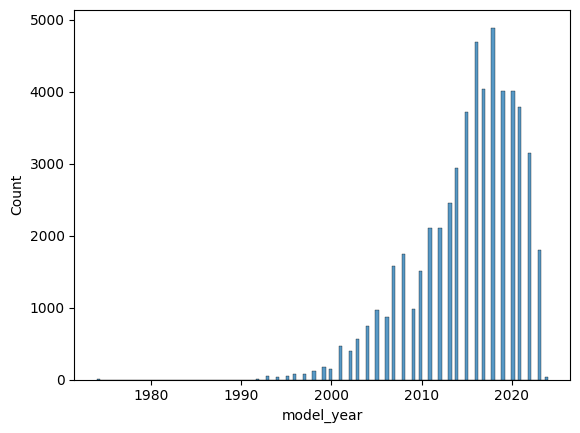

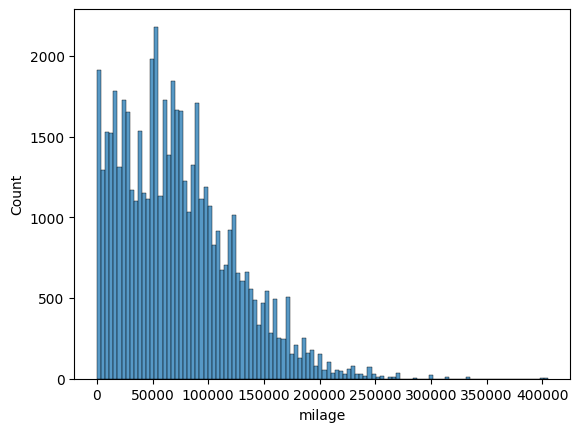

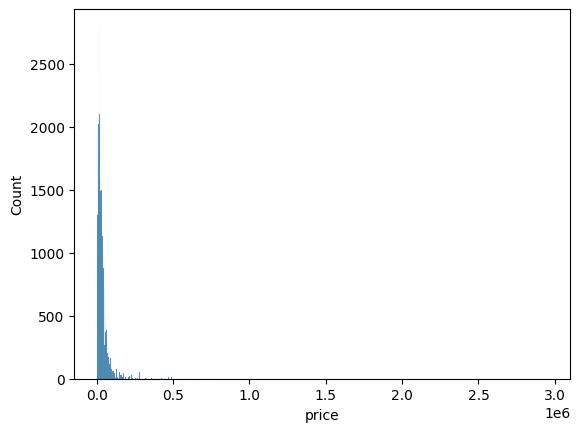

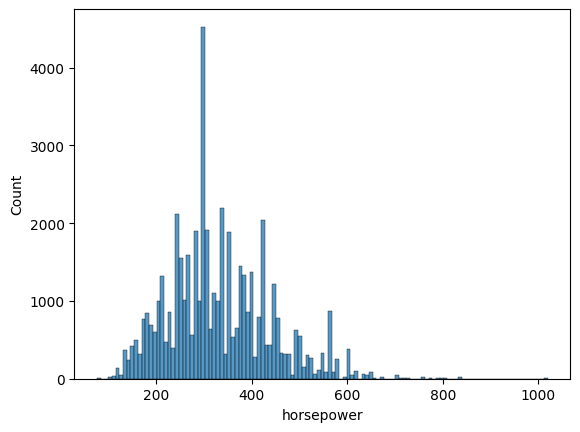

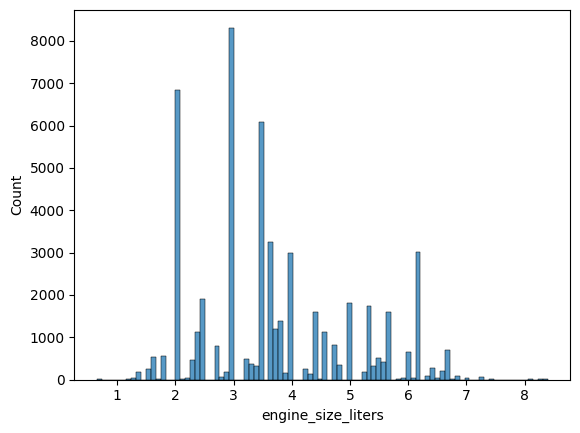

In [26]:
for col in df.select_dtypes('number').columns :
    
    plt.figure()
    sns.histplot(data = df , x = col)

<Axes: xlabel='price', ylabel='Count'>

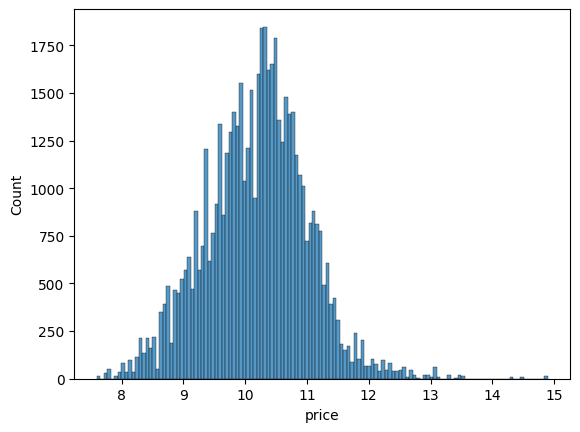

In [27]:
sns.histplot(data = df , x = np.log1p(df['price']))

In [28]:
df[df['milage']>250000]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
111,Volvo,2004,257700,Gasoline,Manual,Red,beige,8000,218.0,2.5,cyl_5
159,Toyota,2012,269885,Gasoline,Automatic,Black,brown,47500,381.0,5.7,cyl_8
720,Toyota,2016,269885,Gasoline,Automatic,Black,black,29500,381.0,5.7,cyl_8
1082,Ford,1999,300183,Gasoline,Automatic,Black,gray,25500,220.0,4.6,cyl_8
1240,Ford,2011,271000,Gasoline,Automatic,Red,gray,9500,300.0,5.4,cyl_8
...,...,...,...,...,...,...,...,...,...,...,...
52036,Ford,2022,251634,Diesel,Automatic,Red,black,46500,475.0,6.7,cyl_8
53204,Dodge,2006,300183,Gasoline,Automatic,Blue,gray,6995,345.0,5.7,cyl_8
53580,Dodge,2007,256000,Gasoline,Automatic,Silver,gray,5000,210.0,3.7,cyl_6
53628,Toyota,2018,259500,Gasoline,Automatic,White,Other,197750,NaN,5.7,NaN


In [29]:
df[df['horsepower']>=700]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
511,Dodge,2020,12700,Gasoline,Automatic,Black,black,105000,707.0,6.2,cyl_8
1940,Rivian,2022,211,Gasoline,Automatic,Blue,black,99000,835.0,NaN,NaN
2029,Dodge,2020,50000,Gasoline,Automatic,Black,black,67000,707.0,6.2,cyl_8
2322,Ford,2020,24500,Gasoline,NaN,Blue,black,104000,760.0,5.2,cyl_8
2453,Ford,2021,19200,Gasoline,Automatic,Black,black,82950,760.0,5.2,cyl_8
...,...,...,...,...,...,...,...,...,...,...,...
51597,Ford,2023,2050,Gasoline,NaN,Gray,black,599000,760.0,5.2,cyl_8
52003,Aston,2019,2165,Gasoline,Automatic,Silver,black,96000,715.0,5.2,cyl_12
52016,Lamborghini,2019,6929,Gasoline,Automatic,Blue,black,35999,759.0,6.5,cyl_12
52142,Dodge,2023,1800,Gasoline,NaN,Gray,black,159500,717.0,6.2,cyl_8


In [30]:
df[df['model_year']<=1995]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
58,Mazda,1993,75980,NaN,Automatic,Green,black,90200,NaN,NaN,NaN
238,Ford,1995,119000,NaN,Automatic,Black,gray,97993,NaN,NaN,NaN
641,Porsche,1995,127000,NaN,NaN,Blue,gray,20000,NaN,NaN,NaN
823,Mercedes-Benz,1993,94000,NaN,Automatic,Gray,black,11900,NaN,NaN,NaN
912,Volvo,1995,170000,Gasoline,Automatic,White,black,7500,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
52593,Jaguar,1995,70000,NaN,Automatic,Gold,Other,5500,NaN,NaN,NaN
53208,Nissan,1993,79000,NaN,Automatic,Red,gray,31995,NaN,NaN,NaN
53337,Nissan,1995,89144,NaN,Automatic,White,gray,15000,NaN,NaN,NaN
53935,Toyota,1994,177700,NaN,NaN,Red,beige,31500,NaN,NaN,NaN


In [31]:
len(df[df['price']>500000])

89

In [32]:
df = df[~((df['model_year'] <= 1990) & (df['horsepower'] == 310) & (df['engine_size_liters'] == 3.5) & (df['num_cylinders'] == 6))].reset_index(drop=True)

In [33]:
df[df['price']>2000000]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
5584,Mercedes-Benz,2004,2533,Gasoline,Automatic,White,beige,2954083,302.0,5.0,cyl_8
7620,Chevrolet,2005,231581,Gasoline,Automatic,Gray,beige,2954083,400.0,6.0,cyl_8
7849,GMC,2005,231500,Gasoline,Automatic,Red,beige,2954083,355.0,5.3,cyl_8
10374,Chevrolet,2015,23442,Gasoline,Automatic,Red,gray,2954083,355.0,5.3,cyl_8
13913,Chevrolet,2006,110000,Gasoline,NaN,Red,beige,2954083,355.0,5.3,cyl_8
14389,GMC,2006,231500,Gasoline,Automatic,Red,gray,2954083,295.0,5.3,cyl_8
19661,Audi,2017,54500,Diesel,Automatic,Black,brown,2954083,NaN,3.0,cyl_6
20007,RAM,2019,10458,Gasoline,Automatic,Red,black,2954083,NaN,5.7,NaN
29826,Toyota,2002,17300,Gasoline,Automatic,Silver,gray,2954083,381.0,5.7,cyl_8
34049,Acura,2021,2353,Gasoline,Automatic,Red,ebony,2954083,NaN,2.0,NaN


In [34]:
df[df['horsepower']>=600]

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
25,Chevrolet,2016,49000,Gasoline,Manual,White,black,65000,650.0,6.2,cyl_8
225,Ford,2022,17900,Gasoline,Automatic,Gray,brown,85000,611.0,3.9,cyl_8
370,BMW,2019,41000,Gasoline,Automatic,Black,brown,50000,600.0,4.4,cyl_8
378,Tesla,2023,2857,Gasoline,Automatic,Black,beige,103500,670.0,NaN,NaN
382,Mercedes-Benz,2016,41500,Gasoline,Automatic,Gray,black,41500,603.0,4.0,cyl_8
...,...,...,...,...,...,...,...,...,...,...,...
54146,Porsche,2022,8755,Gasoline,Automatic,Gray,black,101999,640.0,3.8,cyl_6
54186,BMW,2021,11102,Gasoline,Automatic,Black,black,86900,600.0,4.4,cyl_8
54214,Mercedes-Benz,2019,9500,Gasoline,Automatic,Black,red,93999,630.0,4.0,cyl_8
54243,Bentley,2018,14806,Gasoline,Automatic,Black,brown,234900,621.0,6.0,cyl_12


In [35]:
def outlier_percentage(df):

    numeric_cols = df.select_dtypes(include=np.number).columns

    results = {}

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - (1.5 * IQR)
        upper = Q3 + (1.5 * IQR)

        n_outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        ).sum()

        percentage = (n_outliers / len(df)) * 100

        results[col] = round(percentage, 2)

    return pd.DataFrame(
        results.items(),
        columns=['Column', 'Outlier %']
    ).sort_values(
        by='Outlier %',
        ascending=False
    )
report = outlier_percentage(df)

print(report)

               Column  Outlier %
2               price       5.71
0          model_year       2.23
1              milage       1.34
3          horsepower       0.73
4  engine_size_liters       0.22


In [36]:
def remove_outliers(df):

    numeric_cols = df.select_dtypes(include=np.number) \
                     .drop(columns=['model_year']) \
                     .columns

    mask = np.ones(len(df), dtype=bool)

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - (1.5 * IQR)
        upper = Q3 + (1.5 * IQR)

        mask &= df[col].between(lower, upper)

    return df[mask]

In [37]:
df = remove_outliers(df)

print(df.shape)

(46349, 11)


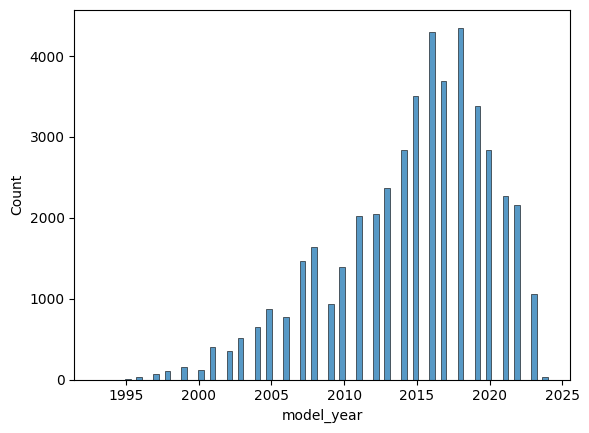

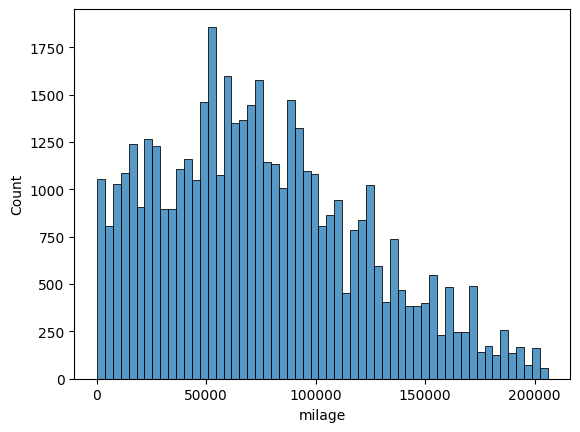

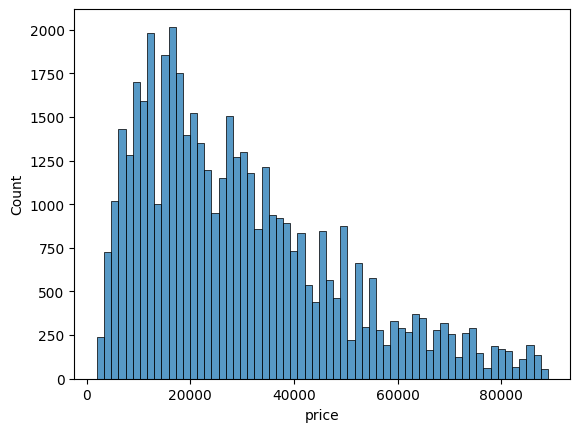

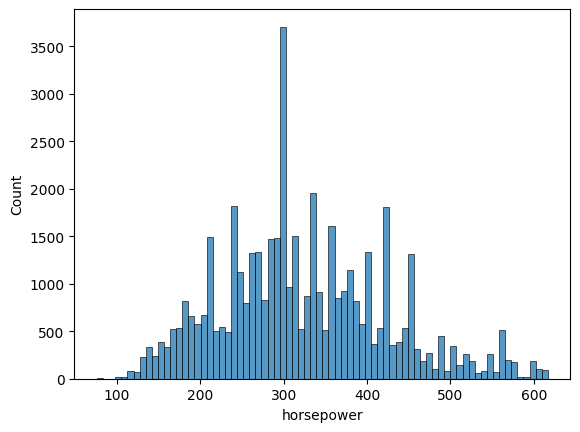

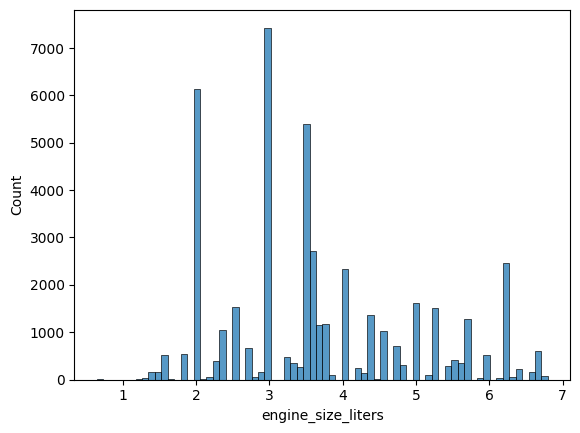

In [38]:
for col in df.select_dtypes('number').columns :
    
    plt.figure()
    sns.histplot(data = df , x = col)

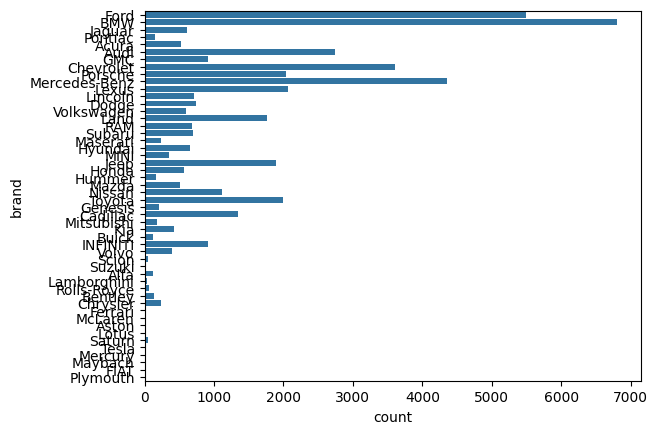

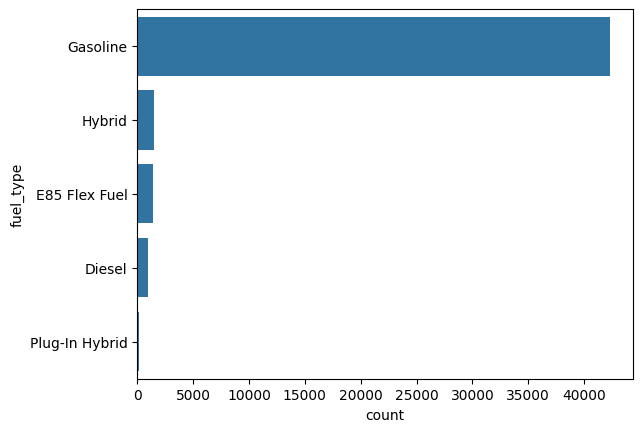

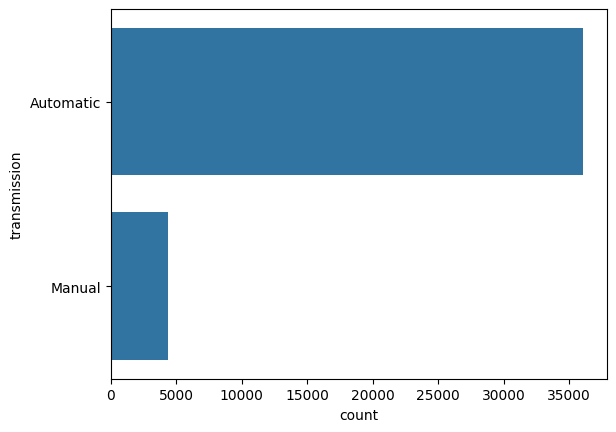

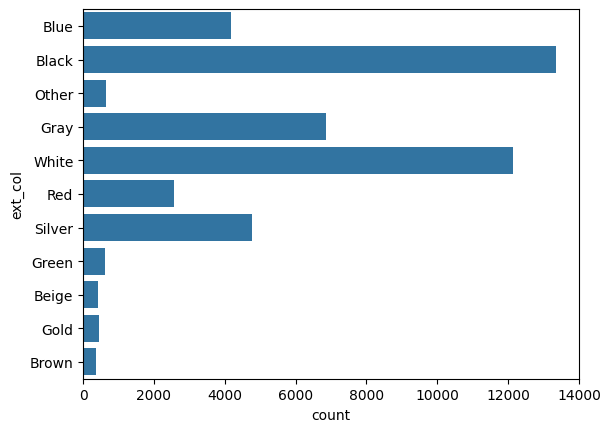

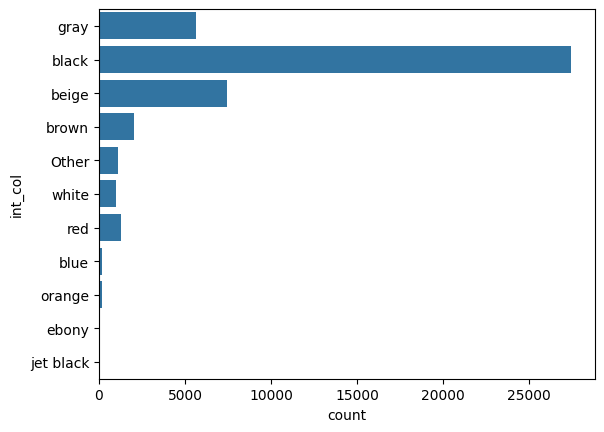

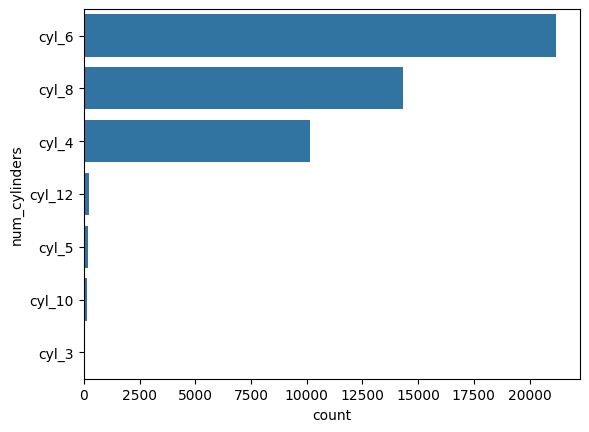

In [39]:
for col in df.select_dtypes('object').columns :
    
    
    plt.figure()
    sns.countplot(data = df , y = col)

In [40]:
top25 = df['brand'].value_counts().head(25).index
df.loc[~df['brand'].isin(top25), 'brand'] = 'Other'

<Axes: xlabel='count', ylabel='brand'>

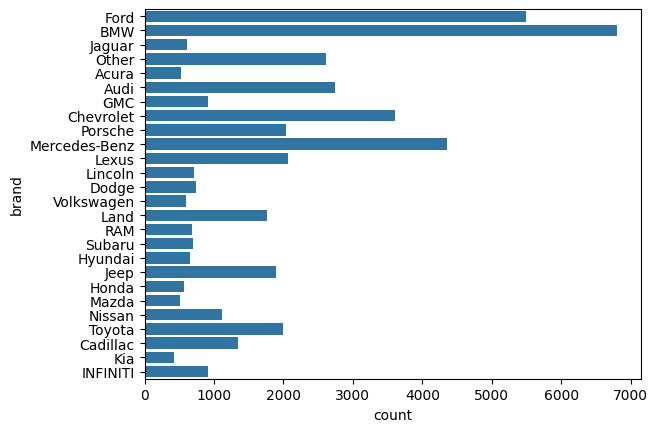

In [41]:
sns.countplot(data = df , y = df['brand'])

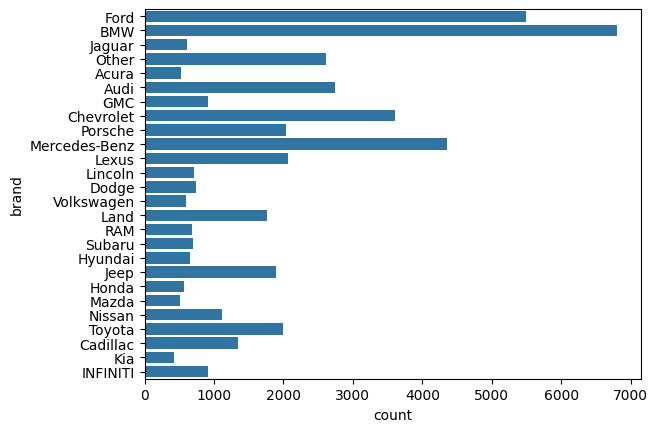

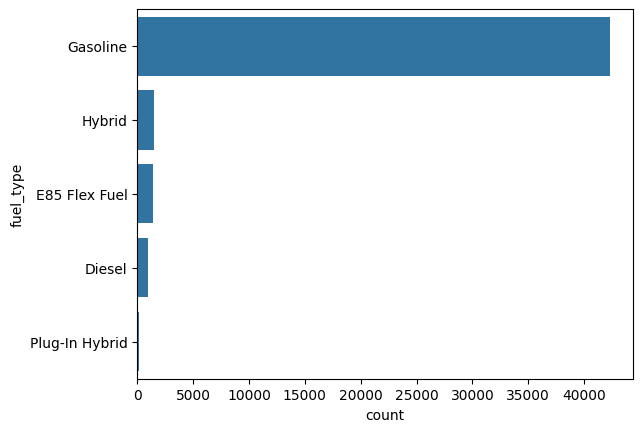

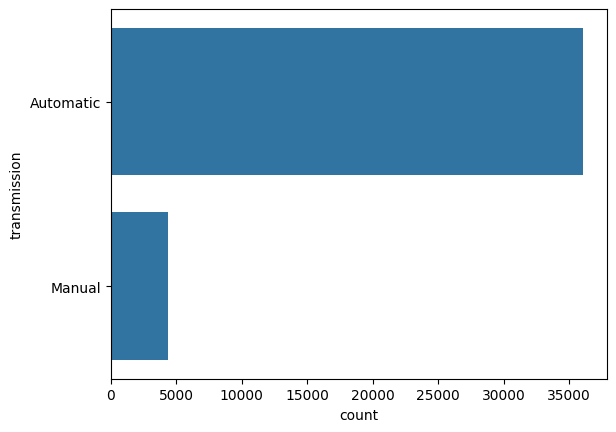

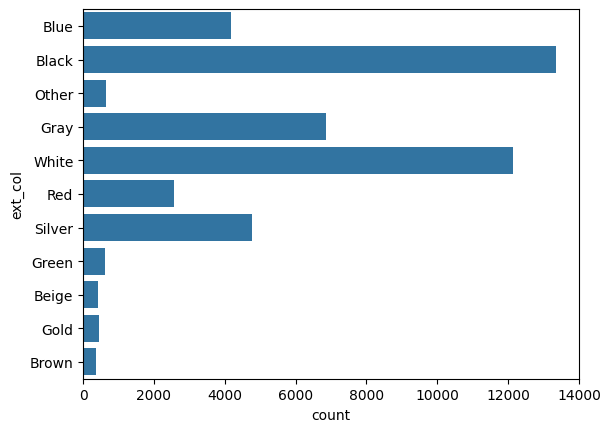

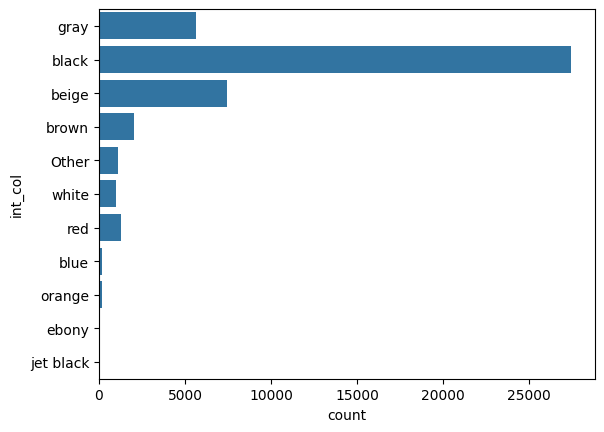

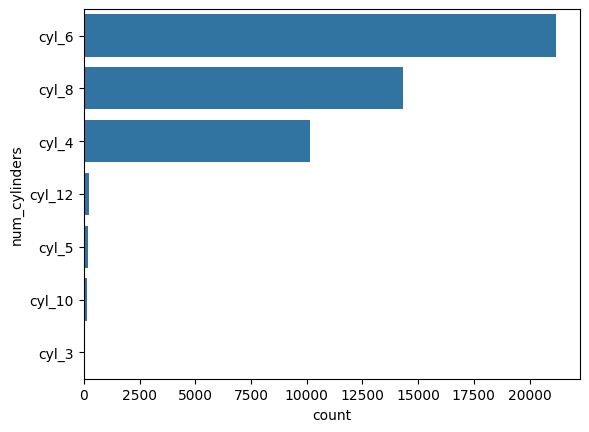

In [42]:
for col in df.select_dtypes('object').columns :
    
    
    plt.figure()
    sns.countplot(data = df , y = col)

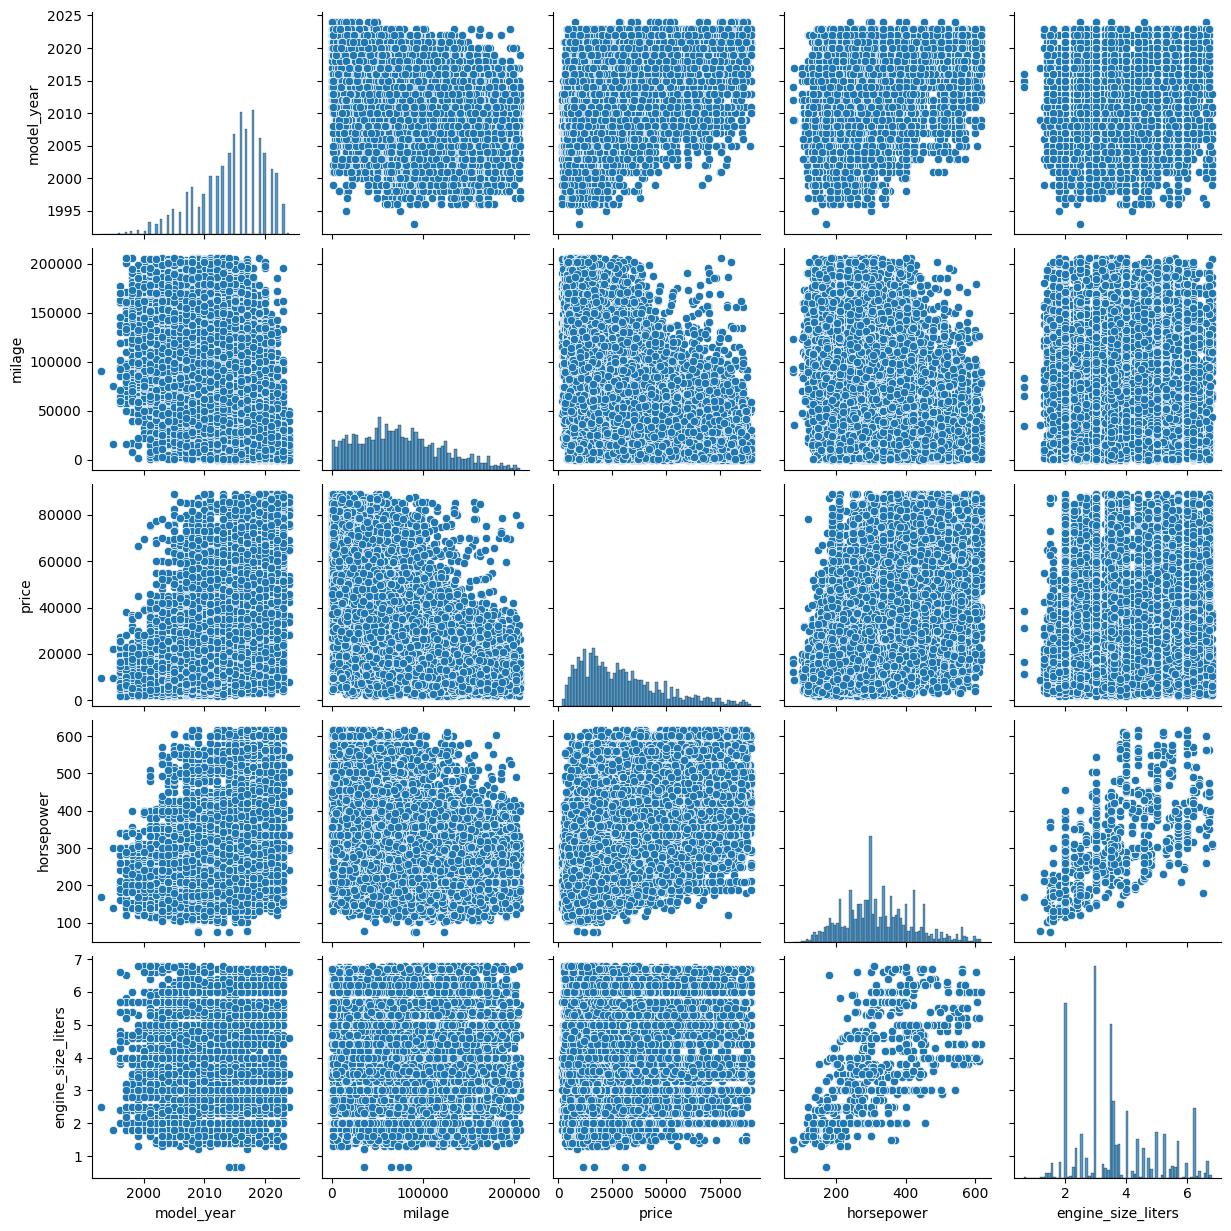

In [43]:
sns.pairplot(df)

<Axes: >

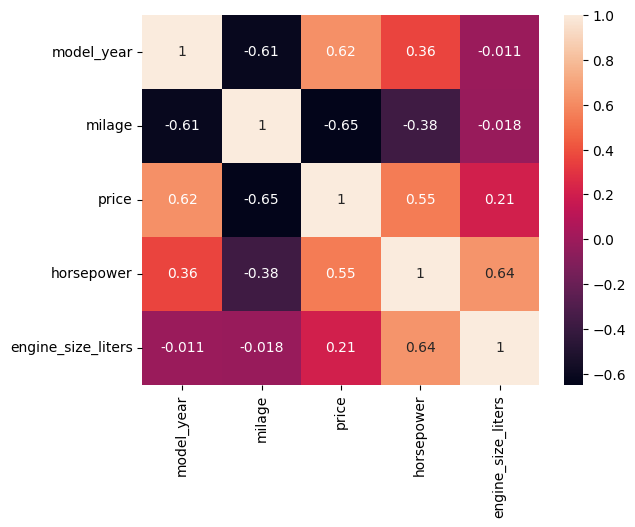

In [44]:
sns.heatmap(df.select_dtypes('number').corr() , annot=True )

# <center> Preprocessing </center>

In [86]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    FunctionTransformer,
    OrdinalEncoder,
    PolynomialFeatures
)

from category_encoders import BinaryEncoder

from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.linear_model import LogisticRegression,LinearRegression, Ridge,BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import(
    GradientBoostingRegressor ,
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor)
from xgboost import XGBRegressor

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel

from sklearn.model_selection import (
    cross_validate,
    GridSearchCV,
    StratifiedKFold,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [46]:
x = df.drop(columns=['price'])
y = np.log1p(df['price'])

* category columns 
>* impute missing + ohe encoder  
>* impute missing + ordinal encoder
* numeric columns 
>* log 
>* Scaling

In [47]:
df.head()

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,price,horsepower,engine_size_liters,num_cylinders
0,Ford,2018,74349,Gasoline,Automatic,Blue,gray,11000,375.0,3.5,cyl_6
1,BMW,2007,80000,Gasoline,Manual,Black,black,8250,300.0,3.0,cyl_6
2,Jaguar,2009,91491,Gasoline,Automatic,Other,beige,15000,300.0,4.2,cyl_8
3,BMW,2022,2437,Hybrid,NaN,Gray,brown,63500,335.0,3.0,cyl_6
4,Other,2001,111000,Gasoline,Automatic,White,black,7850,200.0,3.8,cyl_6


In [48]:
for col in df.select_dtypes('object').columns :
    
    print(f'{col} -- {df[col].nunique()}')
    
    

brand -- 26
fuel_type -- 5
transmission -- 2
ext_col -- 11
int_col -- 11
num_cylinders -- 7


### SequentialFeatureSelector

              feature  importance  importance_percent
1          model_year    0.471793           47.179278
2              milage    0.259098           25.909799
7          horsepower    0.119391           11.939113
5             ext_col    0.040326            4.032571
0               brand    0.031922            3.192207
6             int_col    0.028672            2.867229
8  engine_size_liters    0.026512            2.651231
4        transmission    0.012079            1.207943
3           fuel_type    0.006319            0.631898
9       num_cylinders    0.003887            0.388731


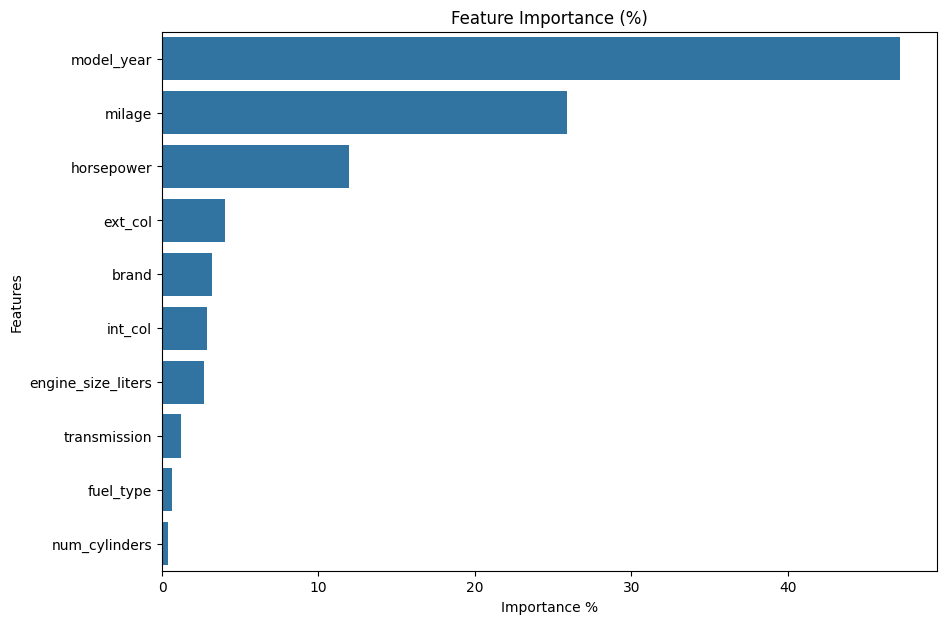

In [49]:
# 1. Copy + Encode objects
X_temp = x.copy()

cat_cols = X_temp.select_dtypes(include='object').columns

X_temp[cat_cols] = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
).fit_transform(X_temp[cat_cols])

# 2. Train model

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_temp, y)


# 3. Feature importance %

importance_df = pd.DataFrame({
    "feature": x.columns,
    "importance": dt.feature_importances_
})

importance_df["importance_percent"] = (
    importance_df["importance"] / importance_df["importance"].sum()
) * 100

importance_df = importance_df.sort_values(
    by="importance_percent",
    ascending=False
)

print(importance_df)


plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    y="feature",
    x="importance_percent"
)

plt.title("Feature Importance (%)")
plt.xlabel("Importance %")
plt.ylabel("Features")

plt.show()

In [50]:
df.isnull().mean()*100

brand                  0.000000
model_year             0.000000
milage                 0.000000
fuel_type              0.006473
transmission          12.694988
ext_col                0.000000
int_col                0.000000
price                  0.000000
horsepower             0.000000
engine_size_liters     0.000000
num_cylinders          0.060411
dtype: float64

In [51]:
ohe_pl = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(
        sparse_output=False,
        drop='first',
        handle_unknown='ignore'
    )
)

ordinal_pl = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=[[
        'cyl_3','cyl_4','cyl_5',
        'cyl_6','cyl_8',
        'cyl_10','cyl_12'
    ]])
)

scale_pl = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

In [52]:
data_preprocessing = ColumnTransformer(
    transformers=[

        ('ohe',
         ohe_pl,
         ['brand','fuel_type',
          'transmission','ext_col','int_col']),

        ('ordinal',
         ordinal_pl,
         ['num_cylinders']),
        ('scale',
         scale_pl,
         ['model_year',
          'horsepower',
          'engine_size_liters','milage'])

    ],
    remainder='passthrough'
)

In [53]:
data_preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [54]:
data_preprocessing.fit_transform(x)

array([[ 0.        ,  0.        ,  0.        , ...,  0.5164868 ,
        -0.13222766, -0.02685389],
       [ 0.        ,  1.        ,  0.        , ..., -0.23258968,
        -0.51292273,  0.09503236],
       [ 0.        ,  0.        ,  0.        , ..., -0.23258968,
         0.40074545,  0.34288141],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -1.0316046 ,
        -1.27431288,  0.41067269],
       [ 0.        ,  0.        ,  0.        , ...,  0.96593269,
        -0.05608864, -0.74639477],
       [ 1.        ,  0.        ,  0.        , ..., -0.62210945,
        -1.27431288, -0.87557134]], shape=(46349, 55))

# <center> Model Selection </center>

In [91]:
models = {

    'Linear Regression (Poly)': make_pipeline(
        data_preprocessing,
        PolynomialFeatures(degree=2, include_bias=False),
        LinearRegression()
    ),

    'Random Forest': make_pipeline(
        data_preprocessing,
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    ),

    'Decision Tree': make_pipeline(
        data_preprocessing,
        DecisionTreeRegressor(
            max_depth=40,
            random_state=42
        )
    ),

    'XGBoost': make_pipeline(
        data_preprocessing,
        XGBRegressor(
            random_state=42,
            n_estimators=200,
            learning_rate=0.05
        )
    ),

    'Gradient Boosting': make_pipeline(
        data_preprocessing,
        GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        )
    ),

    'Bayesian Ridge': make_pipeline(
        data_preprocessing,
        BayesianRidge()
    ),

    'Extra Trees': make_pipeline(
        data_preprocessing,
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    ),

    'Hist Gradient Boosting': make_pipeline(
        data_preprocessing,
        HistGradientBoostingRegressor(
            random_state=42,
            max_depth=10
        )
    ),

    'KNN Regressor': make_pipeline(
        data_preprocessing,
        KNeighborsRegressor(
            n_neighbors=5
        )
    ),

}

In [92]:
results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        x,
        y,
        cv=3,
        scoring={
            'r2': 'r2',
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error'
        },
        return_train_score=True,
        n_jobs=-1
    )

    results[name] = {

        # ===== Train =====
        "Train R2 (%)": round(np.mean(scores['train_r2']) * 100, 2),
        "Train RMSE": round(-np.mean(scores['train_rmse']), 4),
        "Train MAE": round(-np.mean(scores['train_mae']), 4),

        # ===== Test =====
        "Test R2 (%)": round(np.mean(scores['test_r2']) * 100, 2),
        "Test RMSE": round(-np.mean(scores['test_rmse']), 4),
        "Test MAE": round(-np.mean(scores['test_mae']), 4),

        # ===== Stability =====
        "R2 Std": round(np.std(scores['test_r2']), 4),
        "RMSE Std": round(np.std(scores['test_rmse']), 4),
        "MAE Std": round(np.std(scores['test_mae']), 4)
    }

df_results = pd.DataFrame(results).T

df_results = df_results.sort_values(
    by="Test R2 (%)",
    ascending=False
)

display(df_results)

,Train R2 (%),Train RMSE,Train MAE,Test R2 (%),Test RMSE,Test MAE,R2 Std,RMSE Std,MAE Std
XGBoost,74.03,0.3645,0.2716,69.65,0.3940,0.2907,0.0052,0.0023,0.0014
Hist Gradient Boosting,72.00,0.3784,0.2806,69.50,0.3950,0.2916,0.0049,0.0022,0.0013
Gradient Boosting,69.65,0.3940,0.2927,68.77,0.3996,0.2963,0.0056,0.0025,0.0017
Random Forest,95.09,0.1584,0.1148,67.51,0.4077,0.2996,0.0037,0.0014,0.0007
Linear Regression (Poly),69.54,0.3947,0.2923,67.01,0.4108,0.3036,0.0056,0.0025,0.0014
Bayesian Ridge,66.02,0.4169,0.3104,65.91,0.4176,0.3109,0.0036,0.0010,0.0008
Extra Trees,99.48,0.0518,0.0088,64.17,0.4281,0.3158,0.0029,0.0006,0.0010
KNN Regressor,75.31,0.3554,0.2656,62.70,0.4368,0.3264,0.0034,0.0009,0.0009
Decision Tree,99.45,0.0529,0.0093,41.28,0.5480,0.4020,0.0083,0.0054,0.0048


# <center>Random Forest Tuning </center>

In [58]:
pl = make_pipeline(data_preprocessing,RandomForestRegressor())

In [59]:
pl.steps

[('columntransformer',
  ColumnTransformer(remainder='passthrough',
                    transformers=[('ohe',
                                   Pipeline(steps=[('simpleimputer',
                                                    SimpleImputer(strategy='most_frequent')),
                                                   ('onehotencoder',
                                                    OneHotEncoder(drop='first',
                                                                  handle_unknown='ignore',
                                                                  sparse_output=False))]),
                                   ['brand', 'fuel_type', 'transmission',
                                    'ext_col', 'int_col']),
                                  ('ordinal',
                                   Pipeline(steps=[('simpleimputer',
                                                    SimpleImputer(strategy='most_frequent')),
                                                   ('

In [66]:
rf_param = {

'randomforestregressor__n_estimators': [300,500,700,1000],

'randomforestregressor__max_depth': [8,10,12,15,20,None],

'randomforestregressor__min_samples_split': [2,5,10,15,20,30],

'randomforestregressor__min_samples_leaf': [1,2,3,5,8,10],

'randomforestregressor__max_features': ['sqrt','log2',0.3,0.5,0.7],

'randomforestregressor__bootstrap': [True],

'randomforestregressor__max_samples': [0.6,0.7,0.8,0.9]
}

In [ ]:
rf_search = RandomizedSearchCV(

    estimator=models['Random Forest'],

    param_distributions=rf_param,

    scoring='r2',   

    cv=5,

    n_iter=20,

    random_state=42,

    return_train_score=True,
    n_jobs=-1,

    verbose=1
)

rf_search.fit(x, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'randomforestregressor__bootstrap': [True], 'randomforestregressor__max_depth': [8, 10, ...], 'randomforestregressor__max_features': ['sqrt', 'log2', ...], 'randomforestregressor__max_samples': [0.6, 0.7, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref

In [69]:
best_rf = rf_search.best_estimator_
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [ ]:
scores = cross_validate(

    best_rf,

    x,
    y,

    cv=5,

    return_train_score=True,

    scoring={

        'r2': 'r2',

        'rmse': 'neg_root_mean_squared_error',

        'mae': 'neg_mean_absolute_error'
    },

    n_jobs=-1
)

results = {

    "Train R2 (%)": round(scores['train_r2'].mean() * 100, 2),
    "Train RMSE": round(-scores['train_rmse'].mean(), 4),
    "Train MAE": round(-scores['train_mae'].mean(), 4),

    "Test R2 (%)": round(scores['test_r2'].mean() * 100, 2),
    "Test RMSE": round(-scores['test_rmse'].mean(), 4),
    "Test MAE": round(-scores['test_mae'].mean(), 4),

    "R2 Std": round(scores['test_r2'].std(), 4)
}

print(results)

In [65]:
pd.DataFrame([results]).T

,0
Train R2 (%),76.4200
Train RMSE,0.3473
Train MAE,0.2553
Test R2 (%),69.7900
Test RMSE,0.3931
Test MAE,0.2890
R2 Std,0.0027


# <center>XGBoost Tuning </center>

In [93]:
pl = make_pipeline(data_preprocessing,XGBRegressor())

In [94]:
pl.steps

[('columntransformer',
  ColumnTransformer(remainder='passthrough',
                    transformers=[('ohe',
                                   Pipeline(steps=[('simpleimputer',
                                                    SimpleImputer(strategy='most_frequent')),
                                                   ('onehotencoder',
                                                    OneHotEncoder(drop='first',
                                                                  handle_unknown='ignore',
                                                                  sparse_output=False))]),
                                   ['brand', 'fuel_type', 'transmission',
                                    'ext_col', 'int_col']),
                                  ('ordinal',
                                   Pipeline(steps=[('simpleimputer',
                                                    SimpleImputer(strategy='most_frequent')),
                                                   ('

In [106]:
xgb_param = {

    'xgbregressor__n_estimators': [500, 1000, 1500],

    'xgbregressor__learning_rate': [0.01, 0.03, 0.05],

    'xgbregressor__max_depth': [3, 4, 5],

    'xgbregressor__min_child_weight': [1, 3, 5, 7],

    'xgbregressor__subsample': [0.7, 0.8, 0.9],

    'xgbregressor__colsample_bytree': [0.7, 0.8, 0.9],

    'xgbregressor__gamma': [0, 0.1, 0.3, 0.5],

    'xgbregressor__reg_alpha': [0, 0.1, 0.5],

    'xgbregressor__reg_lambda': [1, 1.5, 2, 3]
}

In [107]:
xgb_search = RandomizedSearchCV(

estimator=models['XGBoost'],

param_distributions=xgb_param,

scoring='r2',

cv=5,

n_iter=20,

random_state=42,

return_train_score=True,

n_jobs=-1,

verbose=1
)

xgb_search.fit(x,y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgbregressor__colsample_bytree': [0.7, 0.8, ...], 'xgbregressor__gamma': [0, 0.1, ...], 'xgbregressor__learning_rate': [0.01, 0.03, ...], 'xgbregressor__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the various

In [108]:
best_model = xgb_search.best_estimator_

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

In [109]:
scores = cross_validate(
    best_model,
    x,
    y,
    cv=5,
    return_train_score=True,
    scoring={
        'r2':'r2',
        'rmse':'neg_root_mean_squared_error',
        'mae':'neg_mean_absolute_error'
    },
    n_jobs=-1
)

results = {

"Train R2 (%)": round(scores['train_r2'].mean()*100,2),

"Train RMSE": round(-scores['train_rmse'].mean(),4),

"Train MAE": round(-scores['train_mae'].mean(),4),

"Test R2 (%)": round(scores['test_r2'].mean()*100,2),

"Test RMSE": round(-scores['test_rmse'].mean(),4),

"Test MAE": round(-scores['test_mae'].mean(),4),

"R2 Std": round(scores['test_r2'].std(),4)

}

pd.DataFrame([results]).T

,0
Train R2 (%),74.8700
Train RMSE,0.3586
Train MAE,0.2671
Test R2 (%),70.0900
Test RMSE,0.3912
Test MAE,0.2882
R2 Std,0.0021


In [111]:
xgb_search.best_score_

np.float64(0.7008567666004167)

In [112]:
xgb_search.best_params_

{'xgbregressor__subsample': 0.7,
 'xgbregressor__reg_lambda': 2,
 'xgbregressor__reg_alpha': 0,
 'xgbregressor__n_estimators': 1000,
 'xgbregressor__min_child_weight': 1,
 'xgbregressor__max_depth': 5,
 'xgbregressor__learning_rate': 0.03,
 'xgbregressor__gamma': 0.1,
 'xgbregressor__colsample_bytree': 0.9}

In [110]:
import joblib

joblib.dump(xgb_search.best_estimator_, "xgb_best_model.pkl")

['xgb_best_model.pkl']

In [ ]:
# %%writefile dashboard.py

# import streamlit as st
# import pandas as pd
# import numpy as np
# import joblib
# import plotly.express as px
# import plotly.graph_objects as go

# st.set_page_config(
#     page_title="🚗 Cars Dashboard",
#     layout="wide",
#     page_icon="🚗"
# )

# # ===========================
# # Load Data
# # ===========================

# @st.cache_data
# def load_data():
#     return pd.read_csv("cars_updated_2.csv")

# df = load_data()

# # ===========================
# # Load Model
# # ===========================

# @st.cache_resource
# def load_model():
#     model = joblib.load("xgb_best_model.pkl")
#     return model

# model = load_model()

# # ===========================
# # Sidebar Navigation
# # ===========================

# page = st.sidebar.radio(
#     "Navigation",
#     ["📊 Dashboard", "🤖 Price Prediction"]
# )

# # =====================================================
# # PAGE 1 : DASHBOARD
# # =====================================================

# if page == "📊 Dashboard":

#     st.markdown("""
#     <style>
#         .main { background-color: #0f1117; }
#         .block-container { padding-top: 1.5rem; }
#         h1 { color: #00d4ff; font-size: 2.2rem; text-align: center; }
#         .stMetric label { color: #aaa; }
#     </style>
#     """, unsafe_allow_html=True)

#     st.title("🚗 Cars Market Dashboard")
#     st.markdown("---")

#     k1, k2, k3, k4 = st.columns(4)

#     k1.metric("Total Cars", f"{len(df):,}")
#     k2.metric("Brands", df['brand'].nunique())
#     k3.metric("Avg Price", f"${df['price'].mean():,.0f}")
#     k4.metric("Avg Horsepower", f"{df['horsepower'].mean():,.0f} HP")

#     st.markdown("---")

#     all_brands = sorted(df['brand'].unique())

#     selected_brands = st.sidebar.multiselect(
#         "Filter by Brand",
#         all_brands,
#         default=all_brands[:15]
#     )

#     if selected_brands:
#         df = df[df['brand'].isin(selected_brands)]

#     st.subheader("📊 Sales Volume & Mileage Analysis")

#     col1, col2 = st.columns(2)

#     with col1:

#         yearly = df.groupby(
#             ['brand','model_year']
#         ).size().reset_index(name='count')

#         fig1 = px.bar(
#             yearly,
#             x='model_year',
#             y='count',
#             color='brand',
#             template='plotly_dark',
#             height=430,
#             barmode='stack'
#         )

#         st.plotly_chart(fig1, use_container_width=True)

#     with col2:

#         avg_mil = df.groupby(
#             'brand'
#         )['milage'].mean().reset_index()

#         fig2 = px.bar(
#             avg_mil,
#             x='milage',
#             y='brand',
#             orientation='h',
#             template='plotly_dark',
#             color='milage',
#             height=430
#         )

#         st.plotly_chart(fig2, use_container_width=True)

#     st.markdown("---")

#     st.subheader("🎨 Color Popularity Analysis")

#     col3, col4 = st.columns(2)

#     with col3:

#         ext_counts = df.groupby(
#             ['brand','ext_col']
#         ).size().reset_index(name='count')

#         fig3 = px.bar(
#             ext_counts.head(50),
#             x='count',
#             y='brand',
#             color='ext_col',
#             orientation='h',
#             template='plotly_dark'
#         )

#         st.plotly_chart(fig3, use_container_width=True)

#     with col4:

#         int_counts = df.groupby(
#             ['brand','int_col']
#         ).size().reset_index(name='count')

#         fig4 = px.bar(
#             int_counts.head(50),
#             x='count',
#             y='brand',
#             color='int_col',
#             orientation='h',
#             template='plotly_dark'
#         )

#         st.plotly_chart(fig4, use_container_width=True)

#     st.markdown("---")

#     st.subheader("⚡ Performance & Pricing Analysis")

#     col5, col6 = st.columns(2)

#     with col5:

#         avg_hp = df.groupby(
#             'brand'
#         )['horsepower'].mean().reset_index()

#         fig5 = px.bar(
#             avg_hp,
#             x='brand',
#             y='horsepower',
#             color='horsepower',
#             template='plotly_dark'
#         )

#         st.plotly_chart(fig5, use_container_width=True)

#     with col6:

#         avg_price = df.groupby(
#             'brand'
#         )['price'].mean().reset_index()

#         fig6 = px.bar(
#             avg_price,
#             x='brand',
#             y='price',
#             color='price',
#             template='plotly_dark'
#         )

#         st.plotly_chart(fig6, use_container_width=True)

#     st.markdown("---")

#     st.caption(
#         "Cars Market Analysis Dashboard · Built with Streamlit & Plotly"
#     )

# # =====================================================
# # PAGE 2 : PREDICTION
# # =====================================================

# else:

#     st.title("🤖 Car Price Prediction")

#     st.markdown(
#         "Fill car specifications and predict market price"
#     )

#     col1, col2 = st.columns(2)

#     with col1:

#         brand = st.selectbox(
#             "Brand",
#             sorted(df["brand"].dropna().unique())
#         )

#         fuel_type = st.selectbox(
#             "Fuel Type",
#             sorted(df["fuel_type"].dropna().unique())
#         )

#         transmission = st.selectbox(
#             "Transmission",
#             sorted(df["transmission"].dropna().unique())
#         )

#         ext_col = st.selectbox(
#             "Exterior Color",
#             sorted(df["ext_col"].dropna().unique())
#         )

#         int_col = st.selectbox(
#             "Interior Color",
#             sorted(df["int_col"].dropna().unique())
#         )

#     with col2:

#         num_cylinders = st.number_input(
#             "Cylinders",
#             min_value=2,
#             max_value=16,
#             value=4
#         )

#         milage = st.number_input(
#             "Mileage",
#             min_value=0,
#             value=50000
#         )

#         model_year = st.number_input(
#             "Model Year",
#             min_value=1990,
#             max_value=2035,
#             value=2020
#         )

#         horsepower = st.number_input(
#             "Horsepower",
#             min_value=50,
#             value=200
#         )

#         engine_size_liters = st.number_input(
#             "Engine Size",
#             min_value=0.5,
#             value=2.0
#         )

#     if st.button("Predict Price"):

#         sample = pd.DataFrame({

#             "brand":[brand],
#             "fuel_type":[fuel_type],
#             "transmission":[transmission],
#             "ext_col":[ext_col],
#             "int_col":[int_col],
#             "num_cylinders":[num_cylinders],
#             "milage":[milage],
#             "model_year":[model_year],
#             "horsepower":[horsepower],
#             "engine_size_liters":[engine_size_liters]

#         })

#         pred = model.predict(sample)[0]

#         pred = np.expm1(pred)

#         st.success(
#             f"Estimated Price: ${pred:,.0f}"
#         )